Data for 2000:
Total players: 45
Positions: 8
Position counts:
Position
Pitcher              22
Outfielder           10
Catcher               4
Second Base           3
Designated Hitter     2
Shortstop             2
Third Base            1
First Base            1
Name: count, dtype: int64


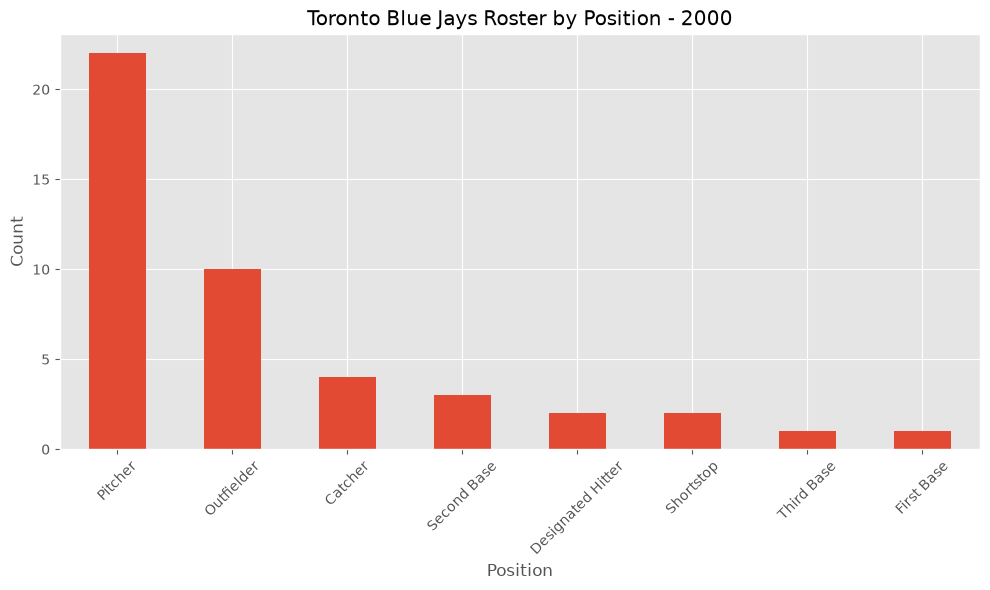

Goodbye Blue Jays fan!


In [17]:
#https://github.com/pseudo-r/Public-MLB-API/blob/main/docs/teams.md
import pandas as pd
import numpy as np
from io import StringIO
import requests
import matplotlib as mpl
import matplotlib.pyplot as plt
teamId = 141 #Toronto Blue Jays
BASE = 'https://statsapi.mlb.com/api/v1'

def ParseData(year):
    try:
        #Get the roster for the Toronto Blue Jays for the {year} season
        response = requests.get(f'{BASE}/teams/{teamId}/roster',
                        params={'season': year},
                        timeout=30)
                
        df = pd.read_json(StringIO(response.text))
        df = df.drop("copyright", axis=1)

        #parsing the roster column into the dataframe
        df = pd.json_normalize(df['roster'])
        #making print statements more readable
        pd.set_option("display.max_colwidth", None)
        df = df.drop("person.link", axis=1)
        df = df.rename(columns={"person.id": "id", 
                                "person.fullName": "Name", 
                                "position.name": "Position", 
                                "position.type": "Position Type", 
                                "position.abbreviation": "Position Abbreviation",
                                "jerseyNumber": "Jersey Number",
                                "position.code": "Position Code",
                                "status.code": "Status Code",
                                "status.description": "Status Description"},)   
        #print(df.head(4))
        df.to_csv(f"roster{year}.csv", index=False)
        return df
    except ValueError as e:
        print(f"Invalid input: {e}")
    except requests.exceptions.RequestException as e:
        print(f"API Request failed: {e}")
    except Exception as e:
        print(f"An error occurred: {e}")

def EvaluateData(df, year):
    print(f"Data for {year}:")
    print(f"Total players: {df['Name'].nunique()}")
    print(f"Positions: {df['Position'].nunique()}")
    print(f"Position counts:\n{df['Position'].value_counts()}")
    

def VisualizeData(df, year):
    try:
        # Visualizing the roster data
        plt.figure(figsize=(10, 6))
        df['Position'].value_counts().plot(kind='bar')
        plt.title(f'Toronto Blue Jays Roster by Position - {year}')
        plt.xlabel('Position')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f"roster{year}.png")
        plt.show()
    except Exception as e:
        print(f"An error occurred during visualization: {e}")

while True:
    year = int(input("Enter the year you want to get the roster for: "))
    if year == 0:
        break

    df = ParseData(year)
    EvaluateData(df, year)
    VisualizeData(df, year)


print("Goodbye Blue Jays fan!")

In [ ]:
def DisplayPersonDetails(name, favoriatePlace, favoriateFood, location):
    return f"Name: {name}, Favorite Place: {favoriatePlace}, Favorite Food: {favoriateFood}, Location: {location}"

print(DisplayPersonDetails("Sean", "PEI", "Sushi", "Vaughan"))

Name: Sean, Favorite Place: PEI, Favorite Food: Sushi,Location: Vaughan
